In [1]:
#Problem: Snomaly detection with Isolation Forest in Credit Card Fraud Detection dataset.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kern

In [4]:
# Setup - run once in a notebook cell:
# !pip install kagglehub

import kagglehub
import pandas as pd
import os

# Downloads the dataset locally (one-time, cached after) using the Kaggle
# dataset identifier - NOT the webpage URL, since Kaggle pages aren't raw files.
dataset_path = kagglehub.dataset_download("saurabhbadole/credit-card-dataset")

# Check the exact filename inside
print(os.listdir(dataset_path))

# Load the actual CSV file (adjust filename based on the print() output above)
df = pd.read_csv(os.path.join(dataset_path, "creditcard.csv"))
print(df.head())

100%|██████████| 66.0M/66.0M [00:39<00:00, 1.77MB/s]

Extracting files...


['creditcard.csv']
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26  

In [10]:
# Step 2: Create Feature and Target datasets.
X = df.drop('Class', axis=1)  # Feature
y = df['Class']  # Target, 0 for normal transaction and 1 for fraud.
y = y.map({0: 1, 1: -1})  # Change for consistency: -1 means anomaly, 1 means normal

# print(y.value_counts())
# print(X.head())
# print(y.head())


In [11]:
# Step 3: Split the data: into training and validation datasets.
# We split into 80-20 ratio. Training (80) and validation (20%)
# stratify=y: This ensures the class distribution (fraud vs. non-fraud) remains consistent in both the training and testing sets.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#print(X_train.shape, X_val.shape)


In [12]:
# Step 4: Build and train the model
model = IsolationForest(contamination=0.01, random_state=42)
# Contamination refers to the proportion of anomalies (outliers) in your dataset. Essentially,
# it’s the expected fraction of the dataset that is considered to be anomalies.
# random_state controls the randomness of the model. It ensures that if you run the algorithm multiple times
# with the same data, you get the same results each time.
model.fit(X_train)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [13]:
# Step 5: Make predictions and Evaluate
# Predict anomalies on test data, (-1, means anomaly, 1 means normal)
predictions = model.predict(X_val)
X_val['anomaly'] = predictions
#print(predictions)

accuracy_score = accuracy_score(y_val, predictions)
print("Accuracy Score:\n", accuracy_score)
confusion_matrix = confusion_matrix(y_val, predictions)
print("Confusion Matrix:\n", confusion_matrix)
classification_report = classification_report(y_val, predictions, zero_division=1)
print("Classfication Report:\n", classification_report)


Accuracy Score:
 0.989431550858467
Confusion Matrix:
 [[   53    45]
 [  557 56307]]
Classfication Report:
               precision    recall  f1-score   support

          -1       0.09      0.54      0.15        98
           1       1.00      0.99      0.99     56864

    accuracy                           0.99     56962
   macro avg       0.54      0.77      0.57     56962
weighted avg       1.00      0.99      0.99     56962



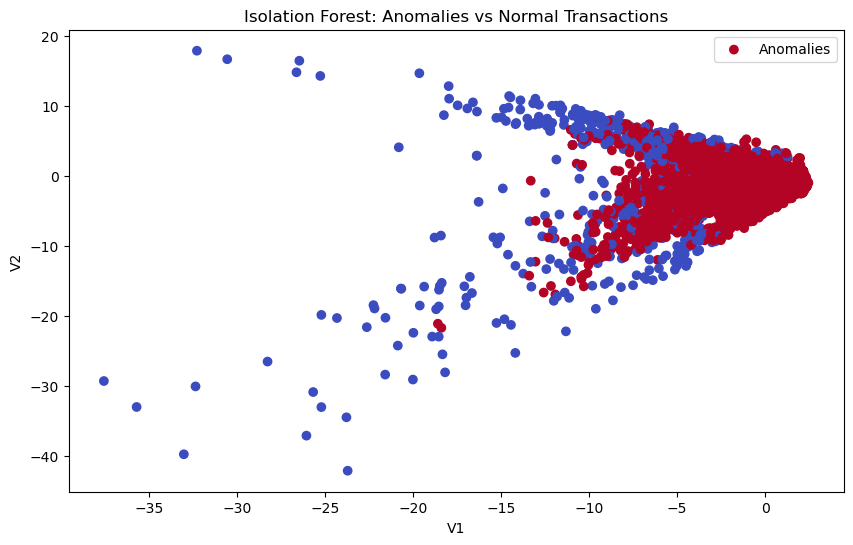

In [14]:
# Step 6: Visualization
# Visualize the anomalies vs normal points using two features (e.g., 'V1' and 'V2')
plt.figure(figsize=(10, 6))
plt.scatter(X_val['V1'], X_val['V2'], c=predictions, cmap='coolwarm', label='Anomalies')
plt.xlabel('V1')
plt.ylabel('V2')
plt.title('Isolation Forest: Anomalies vs Normal Transactions')
plt.legend()
plt.show()

